# Our Own Twist 😌
Our professor has instructed to think of a creative way on where we would integrate a clustering mechanism, understand each step carefully, decide at which step a clustering method can be implemented and generate insights from your results.

## Importing Libraries 📚

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

## Loading the Dataset 🗃️
From a csv file, read and print the first few rows of the data with its columns.

In [5]:
df_full = pd.read_csv("data_censored.csv")
print("Full dataset shape:", df_full.shape)
df_full.head()

Full dataset shape: (725, 12)


,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible
0,1,0,1,1,1.146148,0,0.734203,36,0.083333,0,0,1
1,1,1,1,1,0.002200,0,0.734203,37,0.166667,0,0,0
2,1,2,1,0,-0.481762,0,0.734203,38,0.250000,0,0,0
3,1,3,1,0,0.007872,0,0.734203,39,0.333333,0,0,0
4,1,4,1,1,0.216054,0,0.734203,40,0.416667,0,0,0


## Baseline Rows ➖
We assume that baseline is defined as the first (smallest period) for each id where eligible==1.

In [4]:
df_baseline = (df_full[df_full['eligible'] == 1]
               .sort_values(by=['id', 'period'])
               .groupby('id', as_index=False)
               .first())
print("\nBaseline dataset shape:", df_baseline.shape)
df_baseline.head()


Baseline dataset shape: (89, 12)


,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible
0,1,0,1,1,1.146148,0,0.734203,36,0.083333,0,0,1
1,2,0,0,1,-0.802142,0,-0.990794,26,-0.750000,0,0,1
2,3,0,1,0,0.571029,1,0.391966,48,1.083333,0,0,1
3,4,0,0,0,-0.107079,1,-1.613258,29,-0.500000,0,0,1
4,5,0,1,1,0.749092,0,1.620330,32,-0.250000,0,0,1


## Baseline Covariate Clustering Using the Elbow Method ✳️
This code selects baseline features (x1, x2, x3, x4, age, age_s) and applies KMeans clustering for 1 to 10 clusters. It computes the within-cluster sum-of-squares (WCSS) for each k, then plots these values. The "elbow" point in the plot indicates an optimal number of clusters by showing where additional clusters yield diminishing improvements.

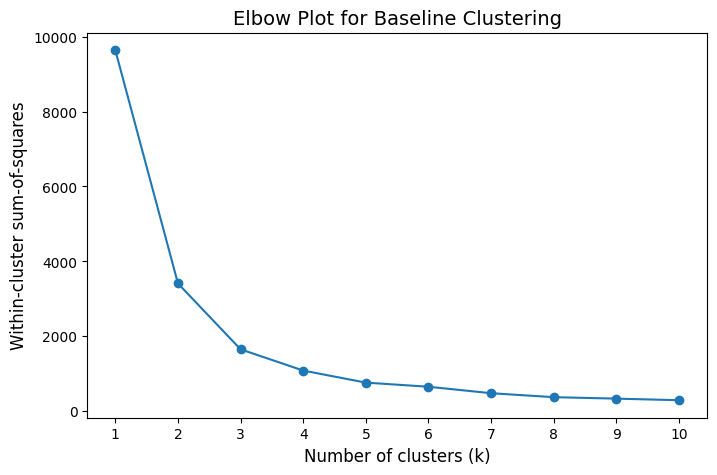

In [8]:
covariates = ['x1', 'x2', 'x3', 'x4', 'age', 'age_s']
X = df_baseline[covariates].copy()

df_baseline.head(5)

wcss = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)
    
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Within-cluster sum-of-squares', fontsize=12)
plt.title('Elbow Plot for Baseline Clustering', fontsize=14)
plt.xticks(k_range)
plt.show()

## K Cluster Plot Insights ✨
From the elbow plot, most of the improvement in clustering (a steep drop in within-cluster sum-of-squares) occurs when moving from 1 to about 3 or 4 clusters. Beyond that point, additional clusters yield diminishing returns. In practical terms, k=3 or k=4 seems like a reasonable balance between cluster compactness and model simplicity.

In [9]:
# Based on the elbow plot, set the number of clusters; here we choose k=3.
k = 3
km_final = KMeans(n_clusters=k, random_state=42)
df_baseline['cluster'] = km_final.fit_predict(X)

## Summarizing and Visualizing Clusters 📝
This provides a quick overview of how each cluster differs in terms of baseline characteristics. Next, it creates a scatter plot of age vs. x2 with cluster assignments indicated by color, allowing a visual sense of how the clusters separate in two dimensions.


Cluster Summary (Baseline covariates):
           x1    x2    x3    x4    age  age_s
cluster                                      
0        0.33 -0.19  0.58  0.50  26.18  -0.73
1        0.45  0.09  0.45 -0.26  40.02   0.42
2        0.44  0.00  0.56 -0.18  52.19   1.43


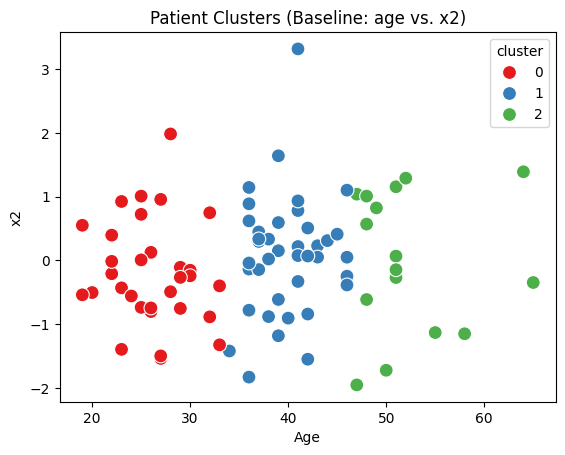

In [12]:
cluster_summary = df_baseline.groupby('cluster')[covariates].mean().round(2)
print("\nCluster Summary (Baseline covariates):")
print(cluster_summary)

# Plot clusters using a pairplot (if dimensions allow) or scatter plot of two chosen variables:
sns.scatterplot(data=df_baseline, x='age', y='x2', hue='cluster', palette='Set1', s=100)
plt.title("Patient Clusters (Baseline: age vs. x2)")
plt.xlabel("Age")
plt.ylabel("x2")
plt.show()

## Insights after Clustering ✨
From this scatter plot of age vs. x2, we can see a clear separation among the three clusters:

* **Cluster 0 (Red).** Tends to group younger individuals with moderately varied x2 values.
* **Cluster 1 (Blue).** Primarily consists of middle-aged individuals spanning a broad x2 range.
* **Cluster 2 (Green).** Generally includes older subjects with mostly lower (or negative) x2 values.

These clusters highlight distinct patient profiles at baseline, at least in terms of age and x2.

## Merging back to Full Dataset 🔀
This code merges the cluster assignments from the baseline data into the complete dataset. By performing a left join on the "id" column, every record in df_full retains its original information while gaining a "cluster" label. The first five rows are then displayed to confirm the successful merge.

In [14]:
df_merged = pd.merge(df_full, df_baseline[['id', 'cluster']], on='id', how='left')
print("\nMerged dataset with cluster labels:")
df_merged.head(5)


Merged dataset with cluster labels:


,id,period,treatment,x1,x2,x3,x4,age,age_s,outcome,censored,eligible,cluster
0,1,0,1,1,1.146148,0,0.734203,36,0.083333,0,0,1,1
1,1,1,1,1,0.002200,0,0.734203,37,0.166667,0,0,0,1
2,1,2,1,0,-0.481762,0,0.734203,38,0.250000,0,0,0,1
3,1,3,1,0,0.007872,0,0.734203,39,0.333333,0,0,0,1
4,1,4,1,1,0.216054,0,0.734203,40,0.416667,0,0,0,1


## Average Treatment Proportion by Cluster ➖
The printed summary shows that Cluster 0 has the highest treatment proportion at 70%, while Clusters 1 and 2 have lower proportions at 41% and 39%, respectively.

In [16]:
treatment_summary = df_merged.groupby('cluster')['treatment'].mean().round(2)
print("\nAverage treatment (proportion) by cluster:")
print(treatment_summary)


Average treatment (proportion) by cluster:
cluster
0    0.70
1    0.41
2    0.39
Name: treatment, dtype: float64


## Visualizing Baseline Covariates by Cluster 📊
It uses kernel density estimates on the diagonal to show the distribution of each variable and displays only the lower triangle for a cleaner layout. The resulting plot helps to visually assess relationships between variables and how these differ across clusters.

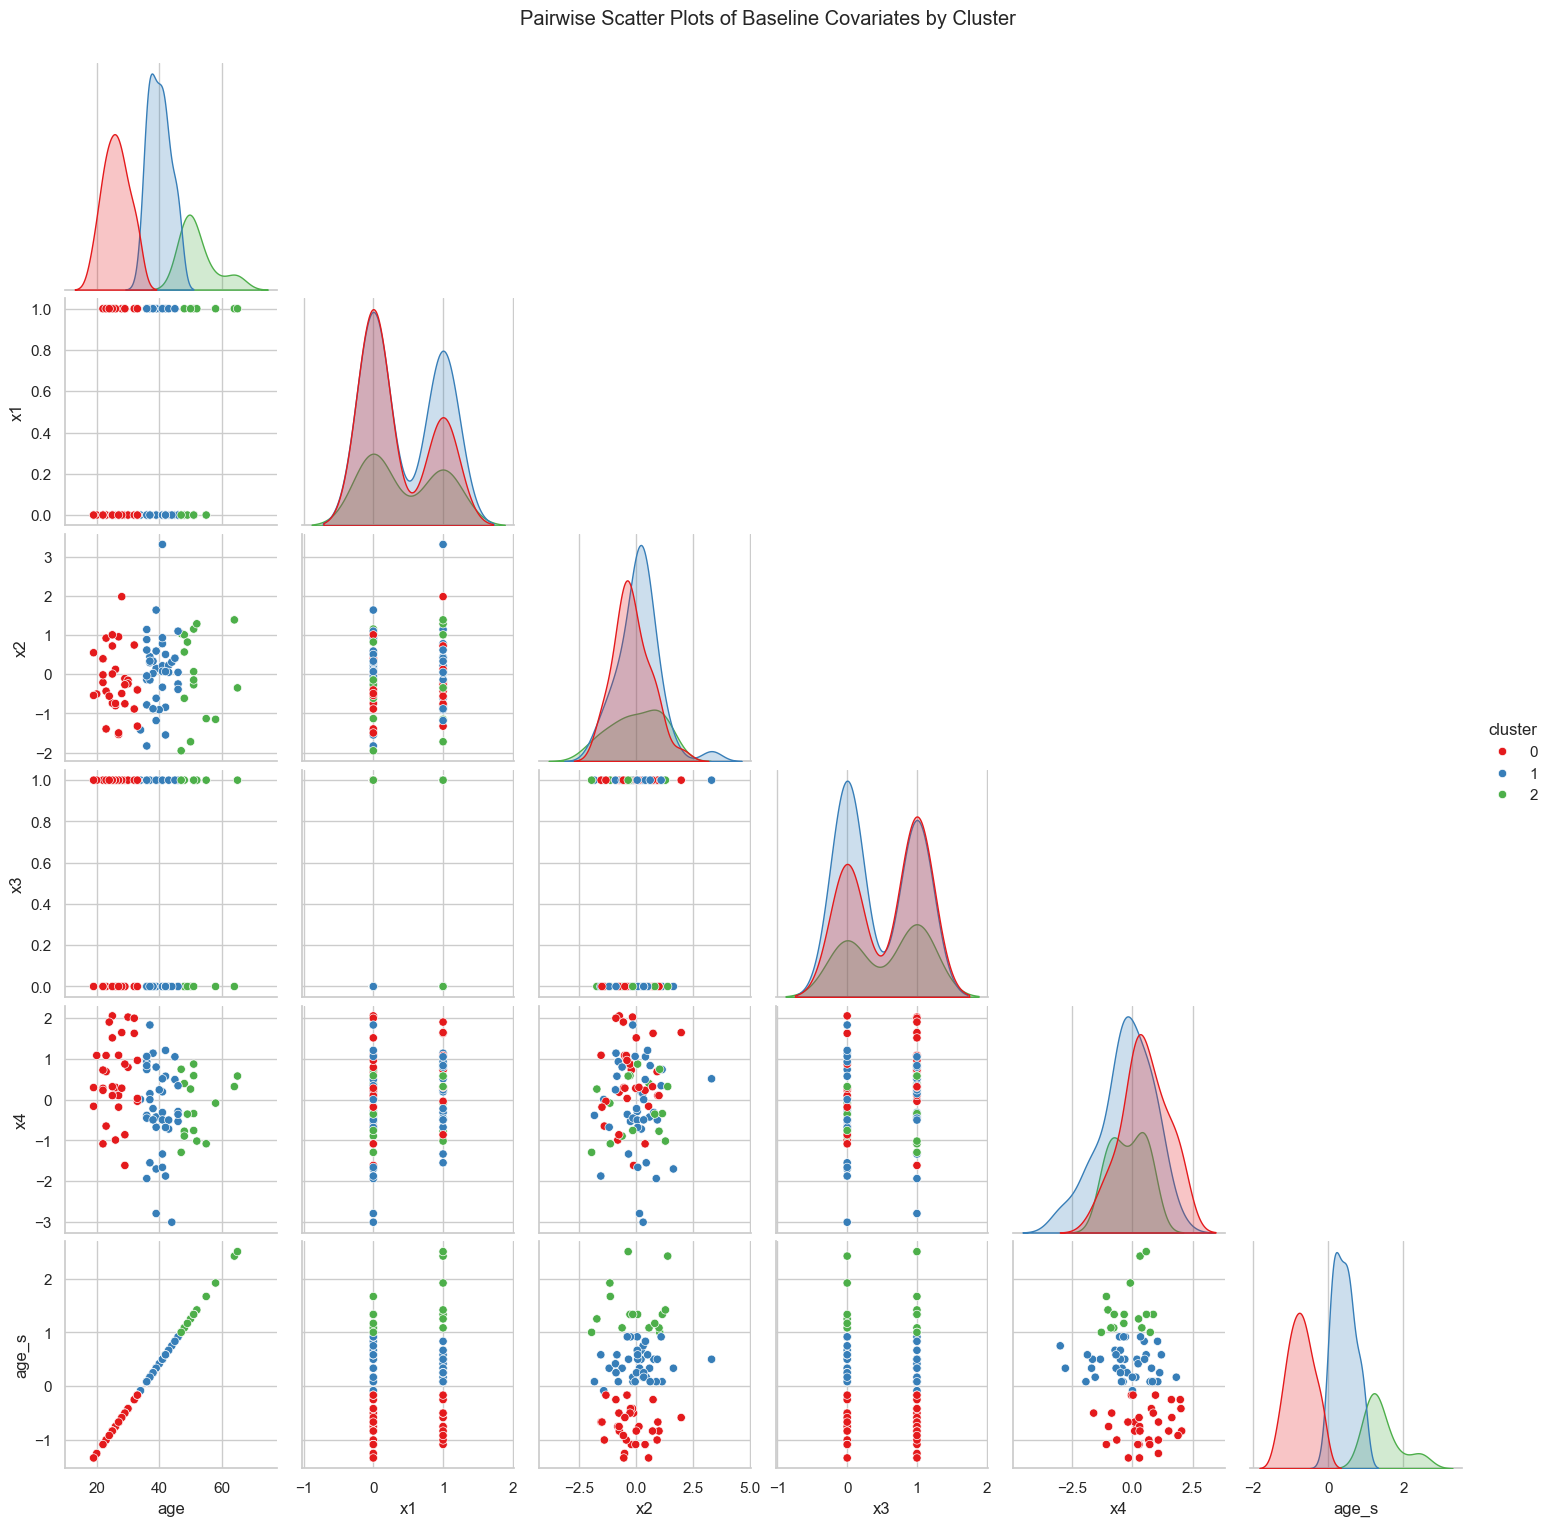

In [ ]:
plot_vars = ['age','x1','x2','x3','x4','age_s']

sns.set(style="whitegrid")
g = sns.pairplot(
    df_baseline, 
    vars=plot_vars, 
    hue='cluster',   # color by cluster
    palette='Set1',  # choose a color palette
    diag_kind='kde', # show kernel density on diagonals
    corner=True      # show only the lower triangle if you want a simpler layout
)

g.fig.suptitle("Pairwise Scatter Plots of Baseline Covariates by Cluster", y=1.02)

plt.show()


## Scatterplot Cluster Insights ✨

1. ***Cluster 0 (red)*** tends to include younger subjects with moderate to higher values in x1–x4.
2. ***Cluster 1 (blue)*** shows a broader spread across most variables, suggesting a middle group that spans a wide range of ages and covariate values.
3. ***Cluster 2 (green)*** skews toward older individuals with lower (often negative) x2 and x3 values.

The diagonal kernel density estimates reinforce these differences in distribution among the clusters, highlighting that each cluster occupies a distinct region in the multidimensional baseline space.

#  Overall Conclusion: Comparing Baseline Clustering vs. TTE Approach 🏆
    Whereas time-to-event (TTE) analyses focus on how treatments and covariates affect outcomes dynamically, this baseline clustering groups individuals solely by their initial characteristics—providing a snapshot of distinct subpopulations before any longitudinal changes. Together, these complementary methods offer a richer view: TTE illuminates time‐dependent effects, while clustering highlights key baseline groupings for deeper insight into patient heterogeneity.